# Preprocessing the data of scRNA-seq with omicverse[CPU-GPU-mixed]

The count table, a numeric matrix of genes × cells, is the basic input data structure in the analysis of single-cell RNA-sequencing data. A common preprocessing step is to adjust the counts for variable sampling efficiency and to transform them so that the variance is similar across the dynamic range. 

Suitable methods to preprocess the scRNA-seq is important. Here, we introduce some preprocessing step to help researchers can perform downstream analysis easyier.

User can compare our tutorial with [scanpy'tutorial](https://scanpy-tutorials.readthedocs.io/en/latest/pbmc3k.html) to learn how to use omicverse well

Colab_Reproducibility：https://colab.research.google.com/drive/1DXLSls_ppgJmAaZTUvqazNC_E7EDCxUe?usp=sharing

In [1]:
import scanpy as sc
import omicverse as ov
ov.plot_set(font_path='Arial')

# Enable auto-reload for development
%load_ext autoreload
%autoreload 2

🔬 Starting plot initialization...
Using already downloaded Arial font from: /tmp/omicverse_arial.ttf
Registered as: Arial
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA L40S
      Memory: 44.5 GB | Compute: 8.9

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 1.7.9   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



<div class="admonition warning">
  <p class="admonition-title">Note</p>
  <p>
    “When OmicVerse is upgraded to version > 1.7.0, it supports CPU–GPU mixed acceleration without requiring `rapids_singlecell` as a dependency—enjoy faster single-cell analysis!”

  </p>
</div>


In [3]:
ov.settings.cpu_gpu_mixed_init()

CPU-GPU mixed mode activated
Available GPU accelerators: CUDA


The data consist of 3k PBMCs from a Healthy Donor and are freely available from 10x Genomics ([here](http://cf.10xgenomics.com/samples/cell-exp/1.1.0/pbmc3k/pbmc3k_filtered_gene_bc_matrices.tar.gz) from this [webpage](https://support.10xgenomics.com/single-cell-gene-expression/datasets/1.1.0/pbmc3k)). On a unix system, you can uncomment and run the following to download and unpack the data. The last line creates a directory for writing processed data.

In [4]:
# !mkdir data
#!wget http://cf.10xgenomics.com/samples/cell-exp/1.1.0/pbmc3k/pbmc3k_filtered_gene_bc_matrices.tar.gz -O data/pbmc3k_filtered_gene_bc_matrices.tar.gz
#!cd data; tar -xzf pbmc3k_filtered_gene_bc_matrices.tar.gz
#!mkdir write

--2026-02-27 04:40:42--  http://cf.10xgenomics.com/samples/cell-exp/1.1.0/pbmc3k/pbmc3k_filtered_gene_bc_matrices.tar.gz
Resolving cf.10xgenomics.com (cf.10xgenomics.com)... 104.18.0.173, 104.18.1.173, 2606:4700::6812:ad, ...
Connecting to cf.10xgenomics.com (cf.10xgenomics.com)|104.18.0.173|:80... connected.
301 Moved Permanentlyaiting response... 
Location: https://cf.10xgenomics.com/samples/cell-exp/1.1.0/pbmc3k/pbmc3k_filtered_gene_bc_matrices.tar.gz [following]
--2026-02-27 04:40:42--  https://cf.10xgenomics.com/samples/cell-exp/1.1.0/pbmc3k/pbmc3k_filtered_gene_bc_matrices.tar.gz
Connecting to cf.10xgenomics.com (cf.10xgenomics.com)|104.18.0.173|:443... connected.
200 OKequest sent, awaiting response... 
Length: 7621991 (7.3M) [application/x-tar]
Saving to: ‘data/pbmc3k_filtered_gene_bc_matrices.tar.gz’

100%[======================================>] 7,621,991   --.-K/s   in 0.1s    

2026-02-27 04:40:42 (65.9 MB/s) - ‘data/pbmc3k_filtered_gene_bc_matrices.tar.gz’ saved [7621991/7

In [5]:
adata = sc.read_10x_mtx(
    'data/filtered_gene_bc_matrices/hg19/',  # the directory with the `.mtx` file
    var_names='gene_symbols',                # use gene symbols for the variable names (variables-axis index)
    cache=True)                              # write a cache file for faster subsequent reading
adata

... writing an h5ad cache file to speedup reading next time


AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'

In [6]:
adata.var_names_make_unique()
adata.obs_names_make_unique()

## Preprocessing

### Quantity control

For single-cell data, we require quality control prior to analysis, including the removal of cells containing double cells, low-expressing cells, and low-expressing genes. In addition to this, we need to filter based on mitochondrial gene ratios, number of transcripts, number of genes expressed per cell, cellular Complexity, etc. For a detailed description of the different QCs please see the document: https://hbctraining.github.io/scRNA-seq/lessons/04_SC_quality_control.html

<div class="admonition warning">
  <p class="admonition-title">Note</p>
  <p>
    if the version of `omicverse` larger than `1.6.4`, the `doublets_method` can be set between `scrublet` and `sccomposite`.
  </p>
</div>

COMPOSITE (COMpound POiSson multIplet deTEction model) is a computational tool for multiplet detection in both single-cell single-omics and multiomics settings. It has been implemented as an automated pipeline and is available as both a cloud-based application with a user-friendly interface and a Python package.

Hu, H., Wang, X., Feng, S. et al. A unified model-based framework for doublet or multiplet detection in single-cell multiomics data. Nat Commun 15, 5562 (2024). https://doi.org/10.1038/s41467-024-49448-x

In [7]:
%%time
adata=ov.pp.qc(
    adata,
    tresh={'mito_perc': 0.2, 'nUMIs': 500, 'detected_genes': 250},
    doublets_method='scrublet',
    batch_key=None,
    filter_doublets=True,
)
adata

⚙️ Using CPU/GPU mixed mode for QC...
NVIDIA CUDA GPUs detected:
📊 [CUDA 0] NVIDIA L40S
    ------------------------------ 4/46068 MiB (0.0%)

🔍 Quality Control Analysis (CPU-GPU Mixed):
   Dataset shape: 2,700 cells × 32,738 genes
   QC mode: seurat
   Doublet detection: scrublet
   Mitochondrial genes: MT-

📊 Step 1: Calculating QC Metrics

   ✓ Gene Family Detection:
   ┌──────────────────────────────┬────────────────────┬────────────────────┐
   │ Gene Family                  │ Genes Found        │ Detection Method   │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Mitochondrial                │ 13                 │ Auto (MT-)         │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Ribosomal                    │ 106                │ Auto (RPS/RPL)     │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Hemoglobin                   │ 13                 │ Auto (regex)       │
   

AnnData object with n_obs × n_vars = 2661 × 13714
    obs: 'nUMIs', 'mito_perc', 'ribo_perc', 'hb_perc', 'detected_genes', 'cell_complexity', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'passing_qc_step1', 'doublet_score', 'predicted_doublet'
    var: 'gene_ids', 'mt', 'ribo', 'hb'
    uns: 'scrublet', 'status', 'status_args', 'REFERENCE_MANU'

### High variable Gene Detection

Here we try to use Pearson's method to calculate highly variable genes. This is the method that is proposed to be superior to ordinary normalisation. See [Article](https://www.nature.com/articles/s41592-023-01814-1#MOESM3) in *Nature Method* for details.


normalize|HVGs：We use | to control the preprocessing step, | before for the normalisation step, either `shiftlog` or `pearson`, and | after for the highly variable gene calculation step, either `pearson` or `seurat`. Our default is `shiftlog|pearson`.

- if you use `mode`=`shiftlog|pearson` you need to set `target_sum=50*1e4`, more people like to se `target_sum=1e4`, we test the result think 50*1e4 will be better
- if you use `mode`=`pearson|pearson`, you don't need to set `target_sum`

<div class="admonition warning">
  <p class="admonition-title">Note</p>
  <p>
    if the version of `omicverse` lower than `1.4.13`, the mode can only be set between `scanpy` and `pearson`.
  </p>
</div>


In [8]:
%%time
adata=ov.pp.preprocess(
    adata,mode='shiftlog|pearson',n_HVGs=2000,
    target_sum=50*1e4,identify_robust=True,
)
adata

🔍 [2026-02-27 04:41:48] Running preprocessing in 'cpu-gpu-mixed' mode...
Begin robust gene identification
    After filtration, 13714/13714 genes are kept.
    Among 13714 genes, 13714 genes are robust.
✅ Robust gene identification completed successfully.
Begin size normalization: shiftlog and HVGs selection pearson

🔍 Count Normalization:
   Target sum: 500000.0
   Exclude highly expressed: True
   Max fraction threshold: 0.2
   ⚠️ Excluding 0 highly-expressed genes from normalization computation
   Excluded genes: []

✅ Count Normalization Completed Successfully!
   ✓ Processed: 2,661 cells × 13,714 genes
   ✓ Runtime: 0.12s

🔍 Highly Variable Genes Selection (Experimental):
   Method: pearson_residuals
   Target genes: 2,000
   Theta (overdispersion): 100

✅ Experimental HVG Selection Completed Successfully!
   ✓ Selected: 2,000 highly variable genes out of 13,714 total (14.6%)
   ✓ Results added to AnnData object:
     • 'highly_variable': Boolean vector (adata.var)
     • 'highly_

AnnData object with n_obs × n_vars = 2661 × 13714
    obs: 'nUMIs', 'mito_perc', 'ribo_perc', 'hb_perc', 'detected_genes', 'cell_complexity', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'passing_qc_step1', 'doublet_score', 'predicted_doublet'
    var: 'gene_ids', 'mt', 'ribo', 'hb', 'n_cells', 'percent_cells', 'robust', 'highly_variable_features', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable'
    uns: 'scrublet', 'status', 'status_args', 'REFERENCE_MANU', 'history_log', 'log1p', 'hvg'
    layers: 'counts'

You can use `recover_counts` to recover the raw counts after normalize and log1p

In [9]:
adata[:,'CD3D'].to_df().T

,AAACATACAACCAC-1,AAACATTGAGCTAC-1,AAACATTGATCAGC-1,AAACCGTGCTTCCG-1,AAACCGTGTATGCG-1,AAACGCACTGGTAC-1,AAACGCTGACCAGT-1,AAACGCTGGTTCTT-1,AAACGCTGTAGCCA-1,AAACGCTGTTTCTG-1,...,TTTCAGTGTCACGA-1,TTTCAGTGTCTATC-1,TTTCAGTGTGCAGT-1,TTTCCAGAGGTGAG-1,TTTCGAACACCTGA-1,TTTCGAACTCTCAT-1,TTTCTACTGAGGCA-1,TTTCTACTTCCTCG-1,TTTGCATGAGAGGC-1,TTTGCATGCCTCAC-1
CD3D,6.718757,0.0,7.371373,0.0,0.0,5.447429,6.132899,6.499361,5.974209,0.0,...,0.0,0.0,0.0,6.532146,0.0,0.0,0.0,0.0,0.0,6.224622


In [15]:
adata[:,'CD3D'].to_df(layer='counts').T

,AAACATACAACCAC-1,AAACATTGAGCTAC-1,AAACATTGATCAGC-1,AAACCGTGCTTCCG-1,AAACCGTGTATGCG-1,AAACGCACTGGTAC-1,AAACGCTGACCAGT-1,AAACGCTGGTTCTT-1,AAACGCTGTAGCCA-1,AAACGCTGTTTCTG-1,...,TTTCAGTGTCACGA-1,TTTCAGTGTCTATC-1,TTTCAGTGTGCAGT-1,TTTCCAGAGGTGAG-1,TTTCGAACACCTGA-1,TTTCGAACTCTCAT-1,TTTCTACTGAGGCA-1,TTTCTACTTCCTCG-1,TTTGCATGAGAGGC-1,TTTGCATGCCTCAC-1
CD3D,4.0,0.0,10.0,0.0,0.0,1.0,2.0,3.0,1.0,0.0,...,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,2.0


In [10]:
X_counts_recovered, size_factors_sub=ov.pp.recover_counts(adata.X, 50*1e4, 50*1e5, log_base=None, 
                                                          chunk_size=10000)
adata.layers['recover_counts']=X_counts_recovered
adata[:,'CD3D'].to_df(layer='recover_counts').T

100%|██████████| 2654/2654 [00:03<00:00, 831.68it/s]


,AAACATACAACCAC-1,AAACATTGAGCTAC-1,AAACATTGATCAGC-1,AAACCGTGCTTCCG-1,AAACCGTGTATGCG-1,AAACGCACTGGTAC-1,AAACGCTGACCAGT-1,AAACGCTGGTTCTT-1,AAACGCTGTAGCCA-1,AAACGCTGTTTCTG-1,...,TTTCAGTGTCACGA-1,TTTCAGTGTCTATC-1,TTTCAGTGTGCAGT-1,TTTCCAGAGGTGAG-1,TTTCGAACACCTGA-1,TTTCGAACTCTCAT-1,TTTCTACTGAGGCA-1,TTTCTACTTCCTCG-1,TTTGCATGAGAGGC-1,TTTGCATGCCTCAC-1
CD3D,4,0,9,0,0,1,2,2,1,0,...,0,0,0,2,0,0,0,0,0,1


Set the .raw attribute of the AnnData object to the normalized and logarithmized raw gene expression for later use in differential testing and visualizations of gene expression. This simply freezes the state of the AnnData object.

In [10]:
%%time
adata.raw = adata
adata = adata[:, adata.var.highly_variable_features]
adata

CPU times: user 9.52 ms, sys: 11 ms, total: 20.5 ms
Wall time: 20.4 ms


View of AnnData object with n_obs × n_vars = 2661 × 2000
    obs: 'nUMIs', 'mito_perc', 'ribo_perc', 'hb_perc', 'detected_genes', 'cell_complexity', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'passing_qc_step1', 'doublet_score', 'predicted_doublet'
    var: 'gene_ids', 'mt', 'ribo', 'hb', 'n_cells', 'percent_cells', 'robust', 'highly_variable_features', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable'
    uns: 'scrublet', 'status', 'status_args', 'REFERENCE_MANU', 'history_log', 'log1p', 'hvg'
    layers: 'counts'

## Principal component analysis

In contrast to scanpy, we do not directly scale the variance of the original expression matrix, but store the results of the variance scaling in the layer, due to the fact that scale may cause changes in the data distribution, and we have not found scale to be meaningful in any scenario other than a principal component analysis

In [11]:
%%time
ov.pp.scale(adata)
adata

    Converting scaled data to csr_matrix format...

╭─ SUMMARY: scale ───────────────────────────────────────────────────╮
│  Duration: 0.7342s                                                 │
│  Shape:    2,661 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● LAYERS │ ✚ scaled (sparse matrix, 2661x2000)                    │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
CPU times: user 571 ms, sys: 262 ms, total: 833 ms
Wall time: 737 ms


AnnData object with n_obs × n_vars = 2661 × 2000
    obs: 'nUMIs', 'mito_perc', 'ribo_perc', 'hb_perc', 'detected_genes', 'cell_complexity', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'passing_qc_step1', 'doublet_score', 'predicted_doublet'
    var: 'gene_ids', 'mt', 'ribo', 'hb', 'n_cells', 'percent_cells', 'robust', 'highly_variable_features', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable'
    uns: 'scrublet', 'status', 'status_args', 'REFERENCE_MANU', 'history_log', 'log1p', 'hvg'
    layers: 'counts', 'scaled'

If you want to perform pca in normlog layer, you can set `layer`=`normlog`, but we think scaled is necessary in PCA.

In [12]:
%%time
ov.pp.pca(adata,layer='scaled',n_pcs=50)
adata

🚀 Using GPU to calculate PCA...
NVIDIA CUDA GPUs detected:
📊 [CUDA 0] NVIDIA L40S
    ------------------------------ 859/46068 MiB (1.9%)
computing PCA🔍
    with n_comps=50

Using CUDA device: NVIDIA L40S
✅ Using built-in torch_pca for GPU-accelerated PCA
   🚀 Using torch_pca PCA for CUDA GPU acceleration
   🚀 torch_pca PCA backend: CUDA GPU acceleration (supports sparse matrices)
   📊 PCA input data type: SparseCSRView, shape: (2661, 2000), dtype: float64
   📊 Sparse matrix density: 100.00%
    finished✅ (12.53s)

╭─ SUMMARY: pca ─────────────────────────────────────────────────────╮
│  Duration: 12.5752s                                                │
│  Shape:    2,661 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ pca                                  

AnnData object with n_obs × n_vars = 2661 × 2000
    obs: 'nUMIs', 'mito_perc', 'ribo_perc', 'hb_perc', 'detected_genes', 'cell_complexity', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'passing_qc_step1', 'doublet_score', 'predicted_doublet'
    var: 'gene_ids', 'mt', 'ribo', 'hb', 'n_cells', 'percent_cells', 'robust', 'highly_variable_features', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable'
    uns: 'scrublet', 'status', 'status_args', 'REFERENCE_MANU', 'history_log', 'log1p', 'hvg', 'pca', 'scaled|original|pca_var_ratios', 'scaled|original|cum_sum_eigenvalues'
    obsm: 'X_pca', 'scaled|original|X_pca'
    varm: 'PCs', 'scaled|original|pca_loadings'
    layers: 'counts', 'scaled'

X_pca converted to PCA to visualize and saved to adata.obsm['PCA']
if you want to use X_pca, please set convert=False


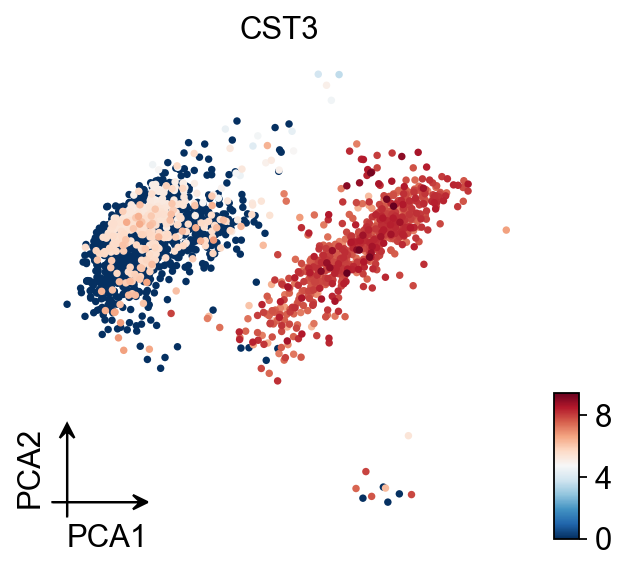

In [15]:
adata.obsm['X_pca']=adata.obsm['scaled|original|X_pca']
ov.pl.pca(adata,color='CST3')

## Embedding the neighborhood graph

We suggest embedding the graph in two dimensions using UMAP (McInnes et al., 2018), see below. It is potentially more faithful to the global connectivity of the manifold than tSNE, i.e., it better preserves trajectories. In some ocassions, you might still observe disconnected clusters and similar connectivity violations. They can usually be remedied by running:

In [16]:
%%time
ov.pp.neighbors(adata, n_neighbors=15, n_pcs=50,
               use_rep='scaled|original|X_pca')

🚀 Using torch CPU/GPU mixed mode to calculate neighbors...
NVIDIA CUDA GPUs detected:
📊 [CUDA 0] NVIDIA L40S
    ------------------------------ 859/46068 MiB (1.9%)

🔍 K-Nearest Neighbors Graph Construction:
   Mode: cpu-gpu-mixed
   Neighbors: 15
   Method: torch
   Metric: euclidean
   Representation: scaled|original|X_pca
   PCs used: 50
   🔍 Computing neighbor distances...
   🔍 Computing connectivity matrix...
   💡 Using UMAP-style connectivity
   ✓ Graph is fully connected

✅ KNN Graph Construction Completed Successfully!
   ✓ Processed: 2,661 cells with 15 neighbors each
   ✓ Results added to AnnData object:
     • 'neighbors': Neighbors metadata (adata.uns)
     • 'distances': Distance matrix (adata.obsp)
     • 'connectivities': Connectivity matrix (adata.obsp)

╭─ SUMMARY: neighbors ───────────────────────────────────────────────╮
│  Duration: 2.8979s                                                 │
│  Shape:    2,661 x 2,000 (Unchanged)                               │
│     

### UMAP
You also can use `umap` to visualize the neighborhood graph

In [17]:
%%time
ov.pp.umap(adata)

🔍 [2026-02-27 04:43:30] Running UMAP in 'cpu-gpu-mixed' mode...
🚀 Using torch GPU to calculate UMAP...
NVIDIA CUDA GPUs detected:
📊 [CUDA 0] NVIDIA L40S
    ------------------------------ 859/46068 MiB (1.9%)

🔍 UMAP Dimensionality Reduction:
   Mode: cpu-gpu-mixed
   Method: pumap
   Components: 2
   Min distance: 0.5
{'n_neighbors': 15, 'method': 'torch', 'random_state': 0, 'metric': 'euclidean', 'use_rep': 'scaled|original|X_pca', 'n_pcs': 50}
   ⚠️ Connectivities matrix was not computed with UMAP method
   🔍 Computing UMAP parameters...
   🔍 Computing UMAP embedding (Parametric PyTorch method)...
   Using device: cuda
   Dataset: 2661 samples × 50 features
   Batch size: 266
   Learning rate: 0.001
   Training parametric UMAP model...
🚀 Parametric UMAP Training
📊 Device: cuda
📈 Data shape: torch.Size([2661, 50])
🔗 Building UMAP graph...
   🚀 Using PyTorch Geometric KNN (faster)

🏋️  Starting Training...
────────────────────────────────────────────────────────────


Training:  15%|█▌        | 3/20 [00:01<00:07]

✓ New best loss: 0.5572
✓ New best loss: 0.3124
✓ New best loss: 0.2870
✓ New best loss: 0.2688


Training:  65%|██████▌   | 13/20 [00:02<00:00]

✓ New best loss: 0.2632



Training: 100%|██████████| 20/20 [00:02<00:00]


────────────────────────────────────────────────────────────
✅ Training Completed!
📉 Final best loss: 0.2632

   💡 Using Parametric UMAP (PyTorch) on cuda

✅ UMAP Dimensionality Reduction Completed Successfully!
   ✓ Embedding shape: 2,661 cells × 2 dimensions
   ✓ Results added to AnnData object:
     • 'X_umap': UMAP coordinates (adata.obsm)
     • 'umap': UMAP parameters (adata.uns)
✅ UMAP completed successfully.

╭─ SUMMARY: umap ────────────────────────────────────────────────────╮
│  Duration: 4.9374s                                                 │
│  Shape:    2,661 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ umap                                                 │
│           │ └─ params: {'a': 0.583030020479462, 'b': 1.3341669929263487}│
│    

X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


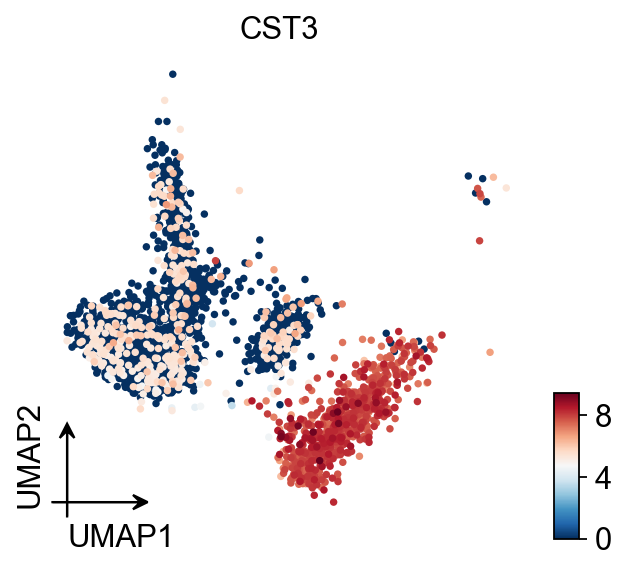

In [18]:
ov.pl.umap(adata,color='CST3')

### MDE

To visualize the PCA’s embeddings, we use the `pymde` package wrapper in omicverse. This is an alternative to UMAP that is GPU-accelerated.

In [19]:
ov.pp.mde(adata,embedding_dim=2,n_neighbors=15, basis='X_mde',
          n_pcs=50, use_rep='scaled|original|X_pca',)

🔍 MDE Dimensionality Reduction:
   Mode: cpu-gpu-mixed
   Embedding dimensions: 2
   Neighbors: 15
   Repulsive fraction: 0.7
   Using representation: scaled|original|X_pca
   Principal components: 50

Using CUDA device: NVIDIA L40S
✅ Using built-in torch_pca for GPU-accelerated PCA
   🔍 Computing k-nearest neighbors graph...
   🔍 Creating MDE embedding...
   🔍 Optimizing embedding...


✅ MDE Dimensionality Reduction Completed Successfully!
   ✓ Embedding shape: 2,661 cells × 2 dimensions
   ✓ Runtime: 3.44s
   ✓ Results added to AnnData object:
     • 'X_mde': MDE coordinates (adata.obsm)
     • 'neighbors': Neighbors metadata (adata.uns)
     • 'distances': Distance matrix (adata.obsp)
     • 'connectivities': Connectivity matrix (adata.obsp)


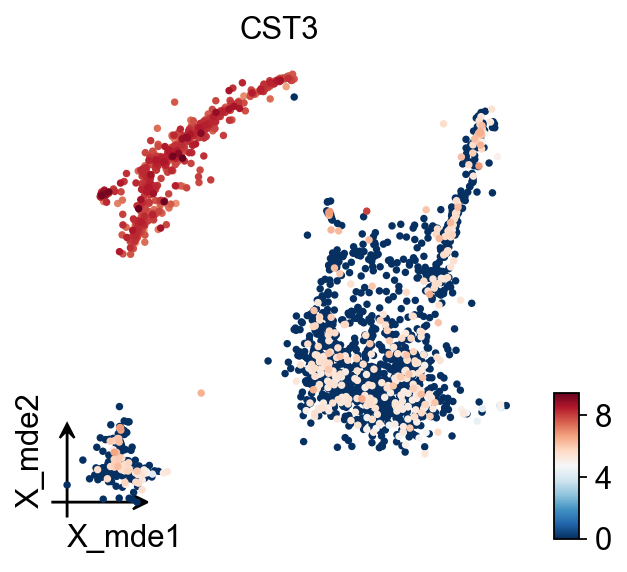

In [20]:
ov.pl.embedding(adata,
                basis='X_mde',
                color='CST3',
                frameon='small')

### TSNE

In [21]:
%%time
ov.pp.tsne(adata,use_rep='scaled|original|X_pca')

⚙️ Using torch CPU/GPU mixed mode to calculate t-SNE...
NVIDIA CUDA GPUs detected:
📊 [CUDA 0] NVIDIA L40S
    ------------------------------ 671/46068 MiB (1.5%)

🔍 t-SNE Dimensionality Reduction:
   Mode: cpu-gpu-mixed
   Components: 2
   Perplexity: 30
   Learning rate: 1000
   🔍 Computing t-SNE with scikit-learn...
   💡 Using scikit-learn TSNE implementation

✅ t-SNE Dimensionality Reduction Completed Successfully!
   ✓ Embedding shape: 2,661 cells × 2 dimensions
   ✓ Results added to AnnData object:
     • 'X_tsne': t-SNE coordinates (adata.obsm)
     • 'tsne': t-SNE parameters (adata.uns)

╭─ SUMMARY: tsne ────────────────────────────────────────────────────╮
│  Duration: 31.0173s                                                │
│  Shape:    2,661 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                        

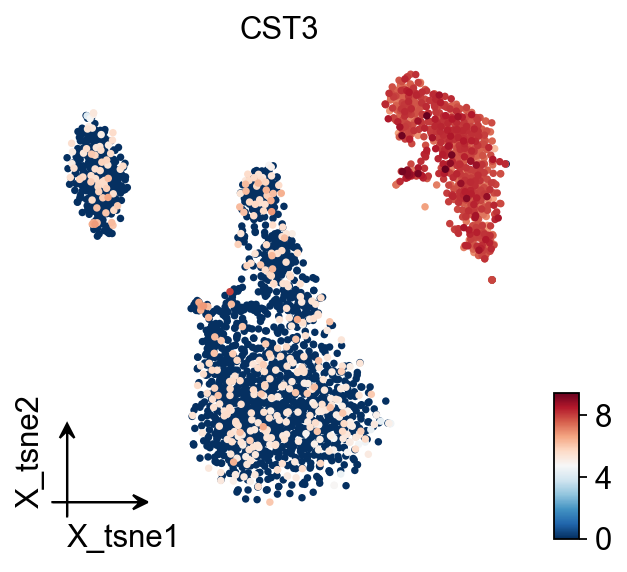

In [22]:
ov.pl.embedding(
    adata,
    basis='X_tsne',
    color='CST3',
    frameon='small'
)

### SUDE

SUDE, a scalable manifold learning method that uses uniform landmark sampling and constrained embedding to preserve both global structure and cluster separability, outperforming t-SNE, UMAP, and related methods across synthetic, real-world, and biomedical datasets.

Cite: Peng, D., Gui, Z., Wei, W. et al. Sampling-enabled scalable manifold learning unveils the discriminative cluster structure of high-dimensional data. Nat Mach Intell (2025). https://doi.org/10.1038/s42256-025-01112-9

In [39]:
%%time
ov.pp.sude(adata,use_rep='scaled|original|X_pca')


🔍 SUDE Dimensionality Reduction:
   Mode: cpu-gpu-mixed
   Components: 2
   Landmarks (k1): 20
   Initialization: le
   🔍 Computing SUDE embedding...
   Parameters:
     • Dimensions: 2
     • K1 landmarks: 20
     • Normalize: True
     • Large scale: False
     • Aggregation coef: 1.2
     • Max epochs: 50


Training epochs: 100%|████████████████████████████| 50/50 [00:01<00:00, 30.81epoch/s]



✅ SUDE Dimensionality Reduction Completed Successfully!
   ✓ Embedding shape: 2,668 cells × 2 dimensions
   ✓ Results added to AnnData object:
     • 'X_sude': SUDE coordinates (adata.obsm)
     • 'sude': SUDE parameters (adata.uns)
CPU times: user 14.1 s, sys: 4.41 s, total: 18.5 s
Wall time: 4.42 s


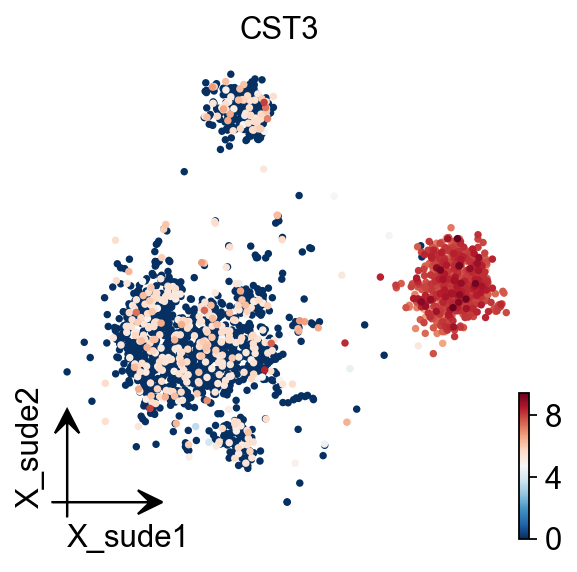

In [40]:
ov.pl.embedding(adata,
                basis='X_sude',
                color='CST3',
                frameon='small')

## Score cell cyle

In OmicVerse, we store both G1M/S and G2M genes into the function (both human and mouse), so you can run cell cycle analysis without having to manually enter cycle genes!

In [5]:
adata_raw=adata.raw.to_adata()
ov.pp.score_genes_cell_cycle(adata_raw,species='human')

calculating cell cycle phase
computing score 'S_score'
    finished: added
    'S_score', score of gene set (adata.obs).
    729 total control genes are used. (0:00:00)
computing score 'G2M_score'
       'ANLN', 'GAS2L3'],
      dtype='object')
    finished: added
    'G2M_score', score of gene set (adata.obs).
    855 total control genes are used. (0:00:00)
-->     'phase', cell cycle phase (adata.obs)

╭─ SUMMARY: score_genes_cell_cycle ──────────────────────────────────╮
│  Duration: 0.1036s                                                 │
│  Shape:    2,661 x 13,714 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBS    │ ✚ G2M_score (float)                                    │
│           │ ✚ S_score (float)                                      │
│           │ ✚ phase (s

X_mde converted to MDE to visualize and saved to adata.obsm['MDE']
if you want to use X_mde, please set convert=False


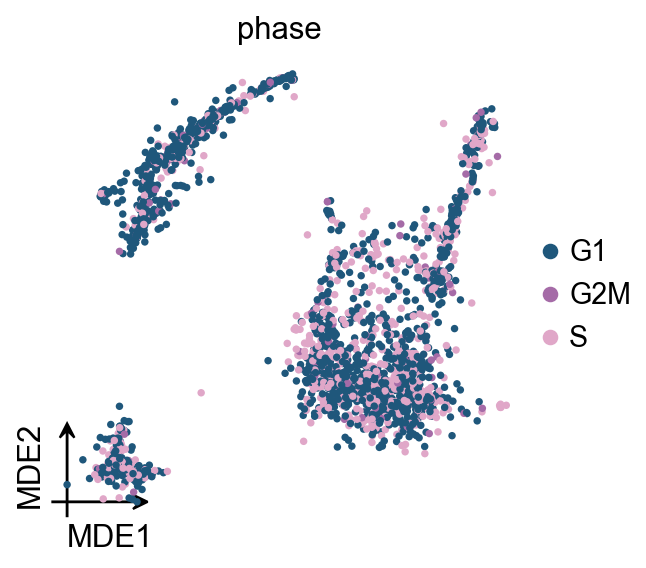

In [10]:
ov.pl.mde(adata_raw,color='phase')

## Clustering the neighborhood graph

As with Seurat and many other frameworks, we recommend the Leiden graph-clustering method (community detection based on optimizing modularity) by Traag *et al.* (2018). Note that Leiden clustering directly clusters the neighborhood graph of cells, which we already computed in the previous section.

In [25]:
ov.pp.leiden(adata,resolution=1)

⚙️ Using torch CPU/GPU mixed mode to calculate Leiden...
NVIDIA CUDA GPUs detected:
📊 [CUDA 0] NVIDIA L40S
    ------------------------------ 671/46068 MiB (1.5%)
Using batch size `n_batches` calculated from sqrt(n_obs): 51
Running GPU Leiden (batched)
Device: cpu


Leiden:   0%|          | 0/10 [00:00<?, ?it/s]

L0 Batched(51):   0%|          | 0/100 [00:00<?, ?it/s]

L1 Batched(51):   0%|          | 0/100 [00:00<?, ?it/s]

L2 Batched(51):   0%|          | 0/100 [00:00<?, ?it/s]

done: 10 clusters (0:00:10)

╭─ SUMMARY: leiden ──────────────────────────────────────────────────╮
│  Duration: 10.078s                                                 │
│  Shape:    2,661 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBS    │ ✚ leiden (category)                                    │
│                                                                    │
│  ● UNS    │ ✚ leiden                                               │
│           │ └─ params: {'resolution': 1, 'random_state': 0, 'local_ite...│
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯


We redesigned the visualisation of embedding to distinguish it from scanpy's embedding by adding the parameter `fraemon='small'`, which causes the axes to be scaled with the colourbar

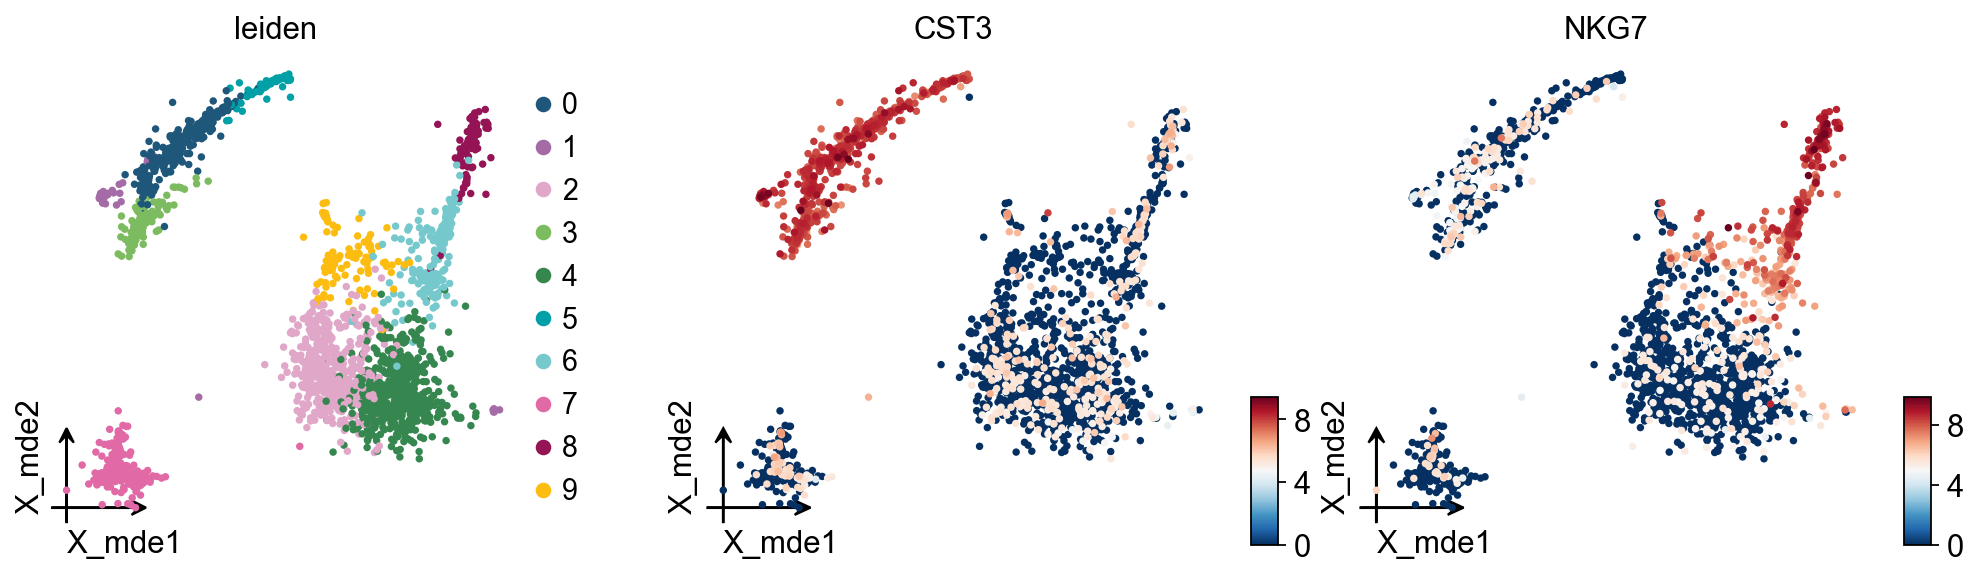

In [11]:
ov.pl.embedding(
    adata,
    basis='X_mde',
    color=['leiden', 'CST3', 'NKG7'],
    frameon='small',
    palette=ov.pl.sc_color
)

We also provide a boundary visualisation function `ov.utils.plot_ConvexHull` to visualise specific clusters.

Arguments: 
- color: if None will use the color of clusters
- alpha: default is 0.2

leiden_colors


<Axes: title={'center': 'leiden'}, xlabel='X_mde1', ylabel='X_mde2'>

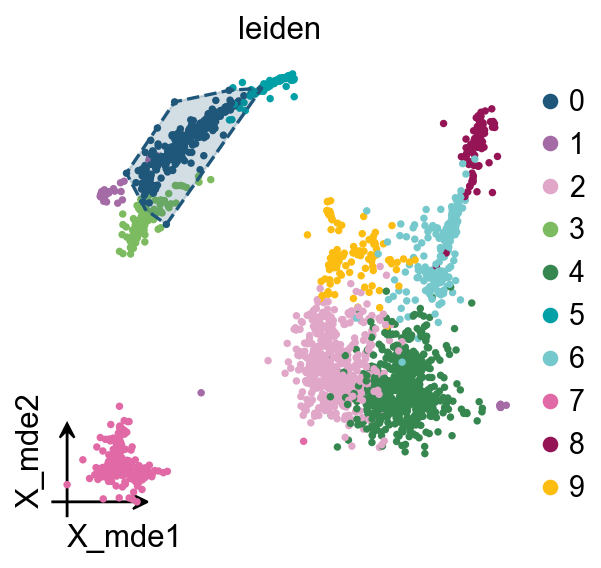

In [12]:
import matplotlib.pyplot as plt
fig,ax=plt.subplots( figsize = (4,4))

ov.pl.embedding(adata,
                basis='X_mde',
                color=['leiden'],
                frameon='small',
                show=False,
                ax=ax)

ov.pl.ConvexHull(adata,
                basis='X_mde',
                cluster_key='leiden',
                hull_cluster='0',
                ax=ax)


If you have too many labels, e.g. too many cell types, and you are concerned about cell overlap, then consider trying the `ov.utils.gen_mpl_labels` function, which improves text overlap.
In addition, we make use of the `patheffects` function, which makes our text have outlines

- adjust_kwargs: it could be found in package `adjusttext`
- text_kwargs: it could be found in class `plt.texts`

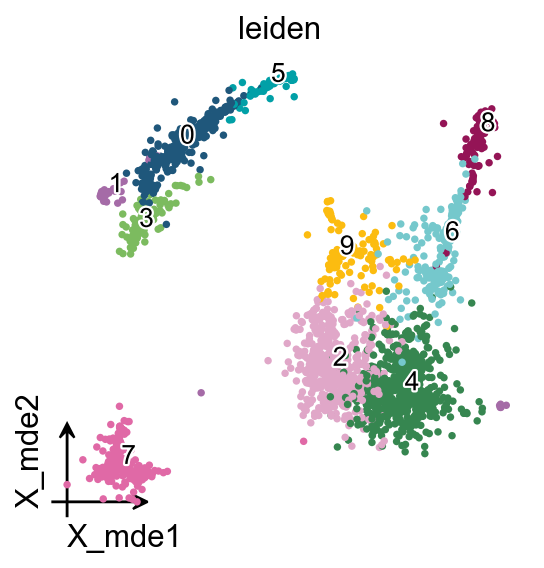

In [13]:
from matplotlib import patheffects
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(4,4))

ov.pl.embedding(
    adata,
    basis='X_mde',
    color=['leiden'],
    show=False, legend_loc=None, add_outline=False, 
    frameon='small',legend_fontoutline=2,ax=ax
)

ov.utils.gen_mpl_labels(
    adata,
    'leiden',
    exclude=("None",),  
    basis='X_mde',
    ax=ax,
    adjust_kwargs=dict(arrowprops=dict(arrowstyle='-', color='black')),
    text_kwargs=dict(fontsize= 12 ,weight='bold',
                     path_effects=[patheffects.withStroke(linewidth=2, foreground='w')] ),
)

In [14]:
marker_genes = ['IL7R', 'CD79A', 'MS4A1', 'CD8A', 'CD8B', 'LYZ', 'CD14',
                'LGALS3', 'S100A8', 'GNLY', 'NKG7', 'KLRB1',
                'FCGR3A', 'MS4A7', 'FCER1A', 'CST3', 'PPBP']

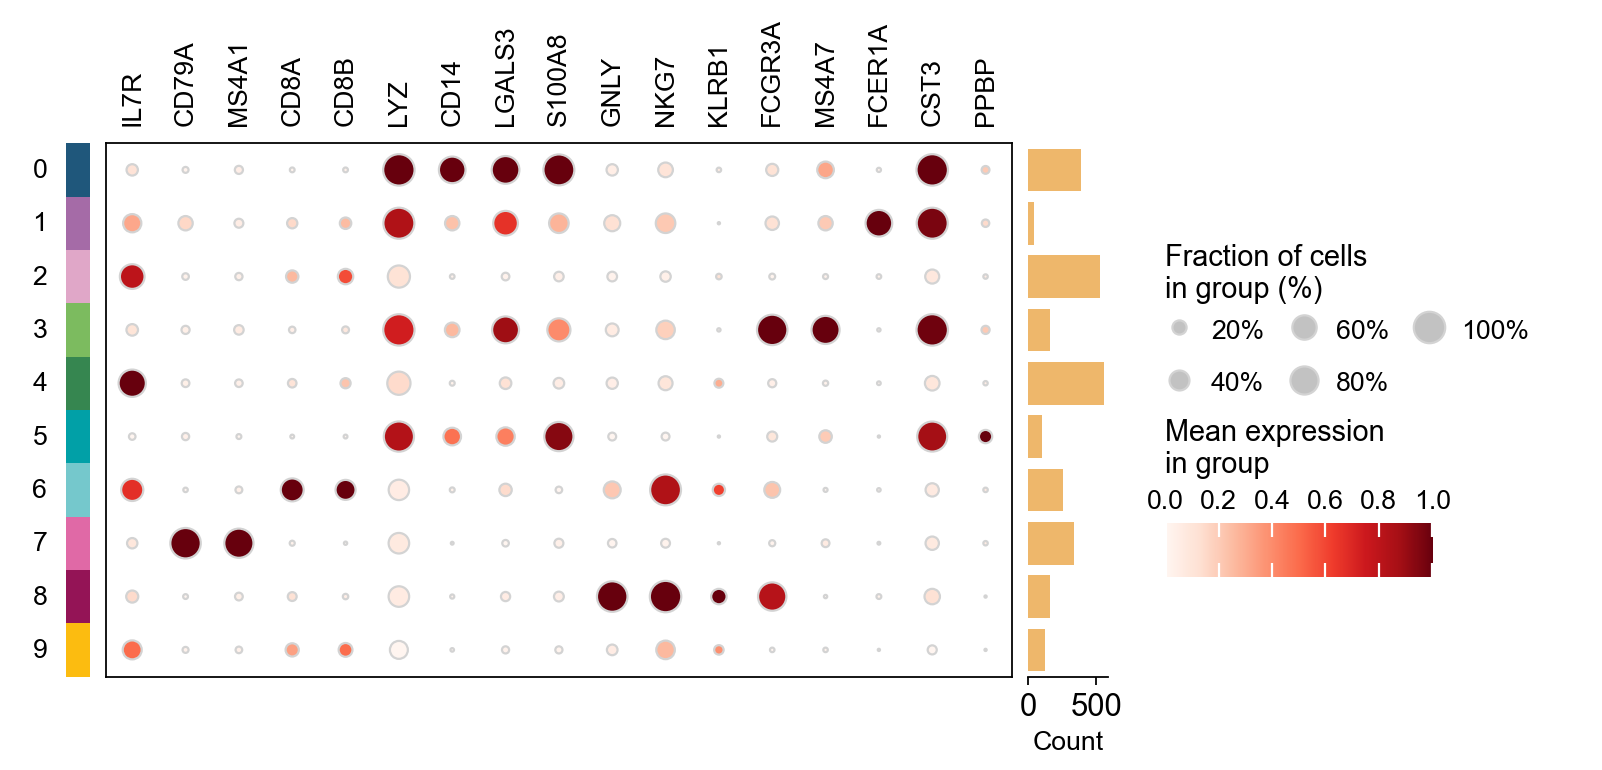

In [15]:
ov.pl.dotplot(adata, marker_genes, groupby='leiden',
             standard_scale='var');

In [31]:
adata.write('data/pbmc_preprocessed_markers.h5ad')

## Finding marker genes

Let us compute a ranking for the highly differential genes in each cluster. For this, by default, the .raw attribute of AnnData is used in case it has been initialized before. The simplest and fastest method to do so is the t-test.

In [16]:
%%time
ov.single.find_markers(
    adata,
    groupby='leiden', 
    method='wilcoxon',#t-test
    key_added="rank_genes_groups",
    pts=True,
)

🔍 Finding marker genes | method: wilcoxon | groupby: leiden | n_groups: 10 | n_genes: 50
✅ Done | 10 groups × 50 genes | corr: benjamini-hochberg | stored in adata.uns['rank_genes_groups']
CPU times: user 2.22 s, sys: 399 ms, total: 2.62 s
Wall time: 2.62 s


In [17]:
ov.single.get_markers(
    adata,
    groups=['0'],
    key = "rank_genes_groups",
)

,group,rank,names,scores,logfoldchanges,pvals,pvals_adj,pct_group,pct_rest
0,0,1,LYZ,30.139215,8.308955,1.485183e-199,2.036780e-195,1.000000,0.536060
1,0,2,S100A9,29.859339,10.341062,6.640705e-196,4.553531e-192,0.997416,0.245822
2,0,3,S100A8,28.556858,10.218678,2.308892e-179,1.055472e-175,0.968992,0.156552
3,0,4,FCN1,28.287178,8.907052,4.969369e-176,1.703748e-172,0.976744,0.176781
4,0,5,TYROBP,28.184223,8.633690,9.127943e-175,2.503612e-171,1.000000,0.292436
5,0,6,CST3,28.036358,8.869659,5.858849e-173,1.339138e-169,1.000000,0.293316
6,0,7,LGALS2,27.883018,9.479619,4.287074e-171,8.398990e-168,0.937984,0.088830
7,0,8,S100A6,27.122936,4.239765,5.282608e-162,8.049520e-159,1.000000,0.743184
8,0,9,GSTP1,26.817543,6.501383,2.017550e-158,2.766869e-155,0.976744,0.367194
9,0,10,FTL,26.692188,3.368342,5.800019e-157,7.231042e-154,1.000000,0.985488


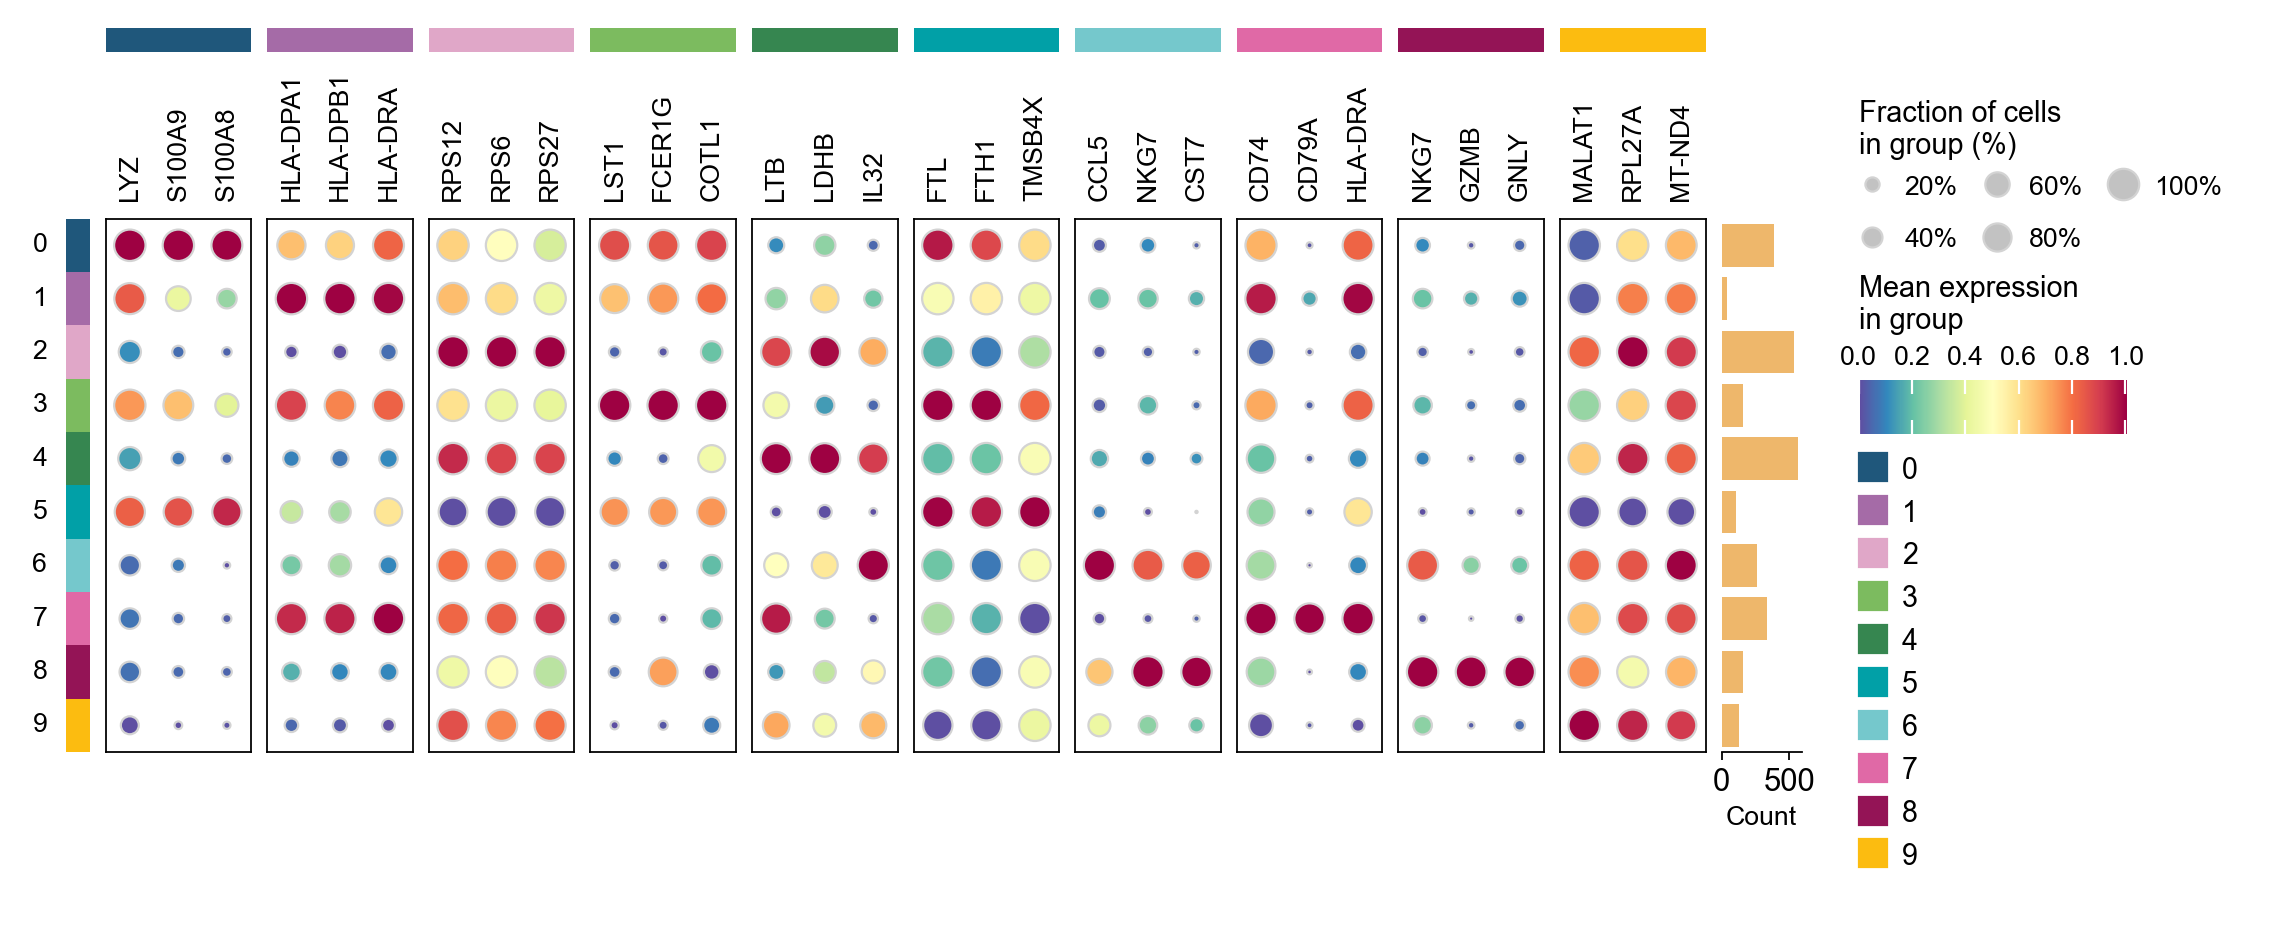

In [18]:
ov.pl.markers_dotplot(
    adata, groupby='leiden', 
    n_genes=3,
    key="rank_genes_groups",
)

cosg is also considered to be a better algorithm for finding marker genes. Here, omicverse provides the calculation of cosg

Paper: [Accurate and fast cell marker gene identification with COSG](https://academic.oup.com/bib/advance-article-abstract/doi/10.1093/bib/bbab579/6511197?redirectedFrom=fulltext)

Code: https://github.com/genecell/COSG


In [19]:
%%time
ov.single.find_markers(
    adata,
    groupby='leiden', 
    method='cosg',#t-test
    key_added="leiden_cosg",
    pts=True,
)

🔍 Finding marker genes | method: cosg | groupby: leiden | n_groups: 10 | n_genes: 50
**finished identifying marker genes by COSG**
✅ Done | 10 groups × 50 genes | stored in adata.uns['leiden_cosg']
CPU times: user 813 ms, sys: 4.63 ms, total: 817 ms
Wall time: 839 ms


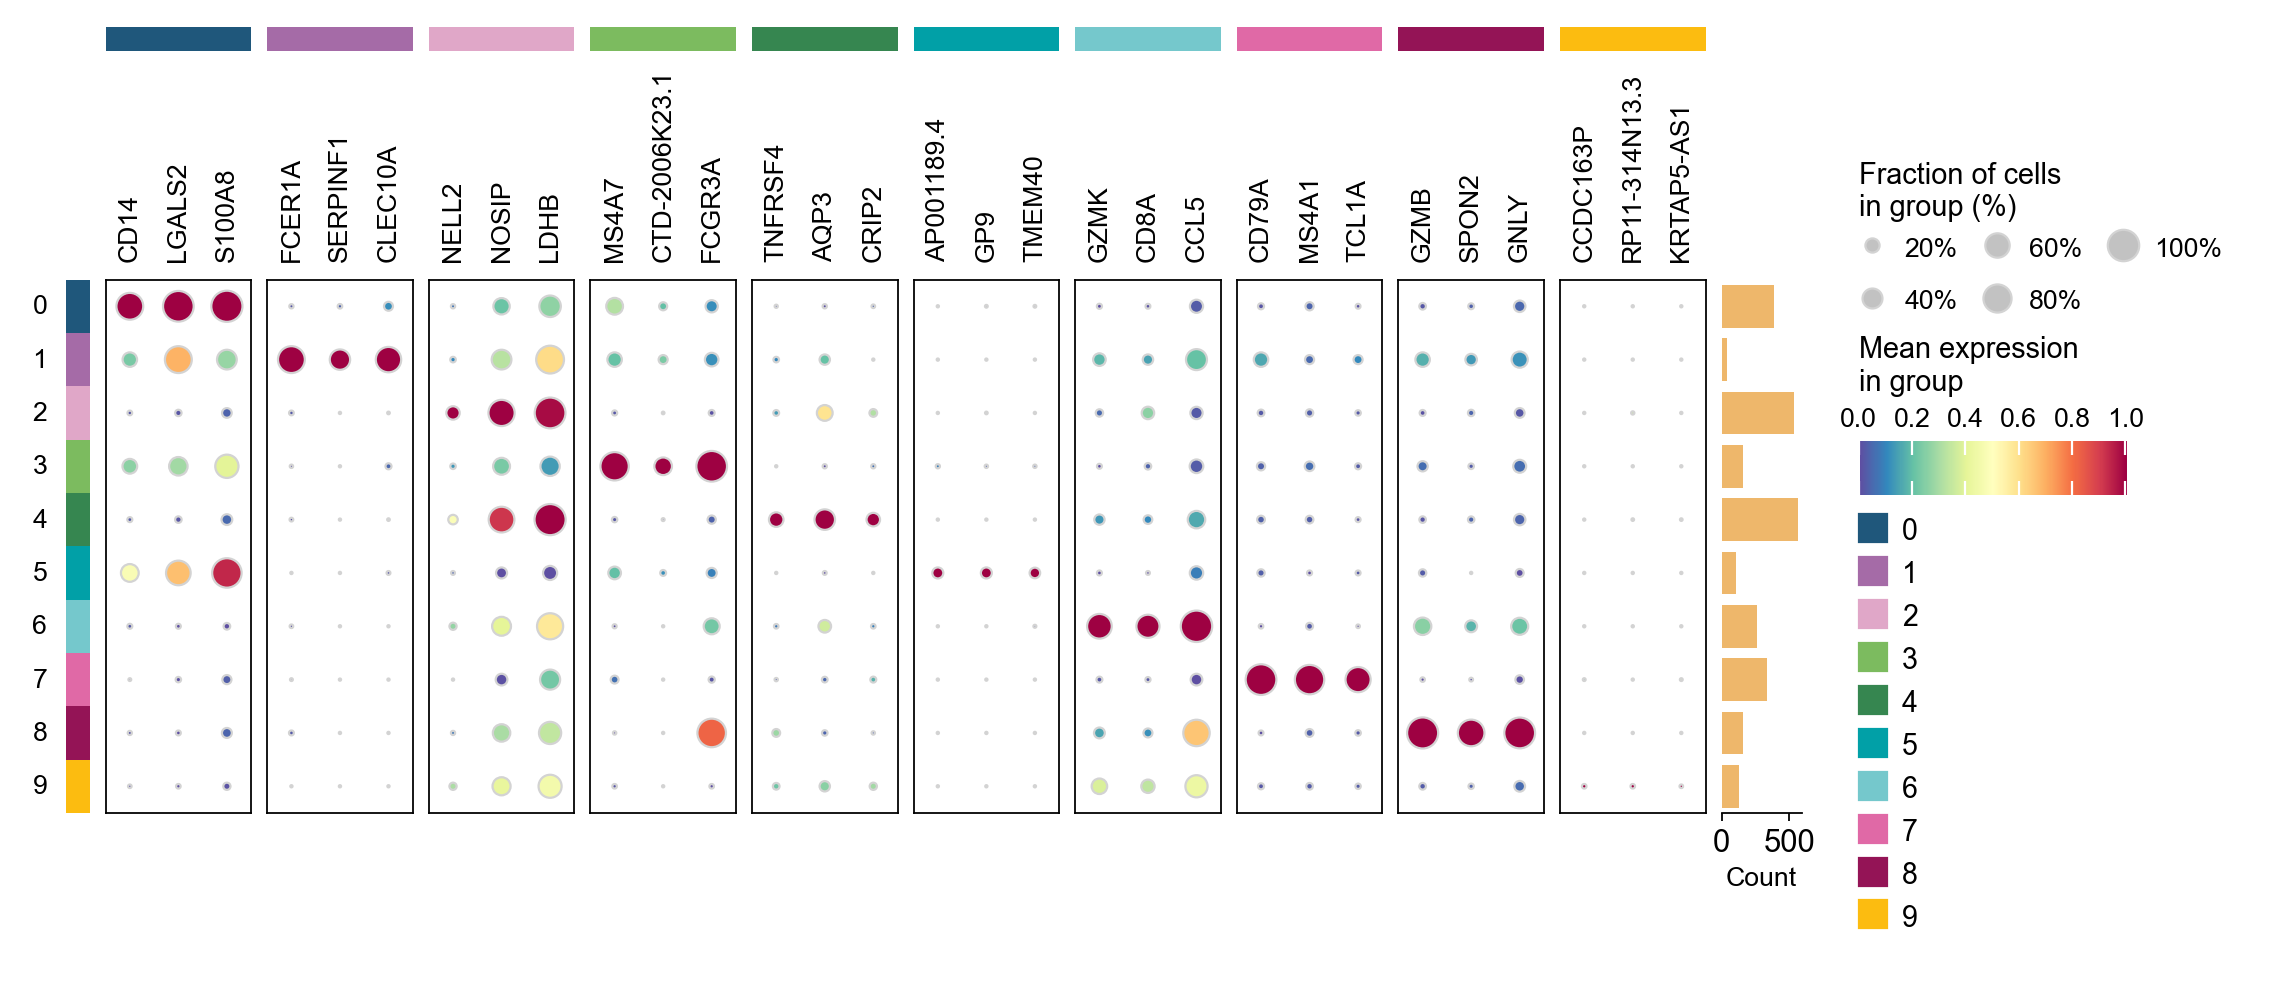

In [20]:
ov.pl.markers_dotplot(
    adata, groupby='leiden', 
    n_genes=3,
    key="leiden_cosg",
)

In [24]:
ov.single.get_markers(
    adata,
    n_genes=20,
    key = "rank_genes_groups",
)

,group,rank,names,scores,logfoldchanges,pvals,pvals_adj,pct_group,pct_rest
0,0,1,LYZ,30.139215,8.308955,1.485183e-199,2.036780e-195,1.000000,0.536060
1,0,2,S100A9,29.859339,10.341062,6.640705e-196,4.553531e-192,0.997416,0.245822
2,0,3,S100A8,28.556858,10.218678,2.308892e-179,1.055472e-175,0.968992,0.156552
3,0,4,FCN1,28.287178,8.907052,4.969369e-176,1.703748e-172,0.976744,0.176781
4,0,5,TYROBP,28.184223,8.633690,9.127943e-175,2.503612e-171,1.000000,0.292436
...,...,...,...,...,...,...,...,...,...
195,9,16,RPS27,3.653990,0.227837,2.581968e-04,1.744291e-02,0.984252,0.994475
196,9,17,MT-CYB,3.345087,-0.051800,8.225686e-04,4.283594e-02,0.874016,0.935280
197,9,18,RPS3,3.297153,0.106617,9.767012e-04,4.870720e-02,0.984252,0.995264
198,9,19,RPS16,3.260641,0.137249,1.111605e-03,5.405871e-02,0.976378,0.985793


In [23]:
ov.single.get_markers(
    adata,
    n_genes=5,
    key = "rank_genes_groups",
    return_type='dict'
)

{'0': ['LYZ', 'S100A9', 'S100A8', 'FCN1', 'TYROBP'],
 '1': ['HLA-DPA1', 'HLA-DPB1', 'HLA-DRA', 'HLA-DRB1', 'CD74'],
 '2': ['RPS12', 'RPS6', 'RPS27', 'RPS14', 'RPL32'],
 '3': ['LST1', 'FCER1G', 'COTL1', 'AIF1', 'IFITM3'],
 '4': ['LTB', 'LDHB', 'IL32', 'CD3D', 'IL7R'],
 '5': ['FTL', 'FTH1', 'TMSB4X', 'OAZ1', 'S100A8'],
 '6': ['CCL5', 'NKG7', 'CST7', 'B2M', 'GZMA'],
 '7': ['CD74', 'CD79A', 'HLA-DRA', 'CD79B', 'HLA-DPB1'],
 '8': ['NKG7', 'GZMB', 'GNLY', 'PRF1', 'CTSW'],
 '9': ['MALAT1', 'RPL27A', 'MT-ND4', 'RPS29', 'MT-CO3']}